### Importing Libraies

#### Standard Library

In [638]:
import os
import sys
import time
import math
import random
import warnings
from datetime import datetime
from collections import defaultdict

warnings.filterwarnings("ignore")

#### Data Science Libraries

In [639]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from numpy import interp

#### Scikit-learn - Model Selection & Preprocessing

In [640]:
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    train_test_split
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.datasets import make_classification

#### Scikit-learn - Models

In [641]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    BaggingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans

# Keep svm namespace for `svm.SVC`
from sklearn import svm as sklearn_svm
svm = sklearn_svm

#### Scikit-learn - Metrics

In [642]:
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

#### Third-party / Optional Libraries

In [643]:
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import lightgbm as lgb
    from lightgbm import early_stopping, log_evaluation
    HAS_LGB = True
except Exception:
    HAS_LGB = False

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception:
    HAS_TF = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    import optuna
    HAS_OPTUNA = True
except Exception:
    HAS_OPTUNA = False


import joblib



#### Config 

In [644]:

OUTPUT_DIR = "hybrid_model_on_PSnoD"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Data Load

##### LSGT

In [645]:
# input_data_dir = "Data"
# disease_name = pd.read_csv(os.path.join(input_data_dir, 'disease_name.csv'),header=None)
# snoRNA_name = pd.read_csv(os.path.join(input_data_dir, 'snoRNA_name.csv'),header=None)

###### Big DataSet


In [646]:
# SnoRNA_similarity = pd.read_csv(os.path.join(input_data_dir, 'snoRNA_similarity.csv'))
# known_association = pd.read_csv(os.path.join(input_data_dir, 'known_snoRNA_disease.csv'), header=None)
# disease_similarity = pd.read_csv(os.path.join(input_data_dir, 'disease_similarity.csv'), header=None)


###### K

In [647]:
# SnoRNA_similarity = pd.read_csv(os.path.join(input_data_dir, 'IRS_matrix.csv'), header=None)
# known_association = pd.read_csv(os.path.join(input_data_dir, 'known_snoRNA_disease.csv'), header=None)
# disease_similarity = pd.read_csv(os.path.join(input_data_dir, 'IDS_matrix.csv'), header=None)


###### I

In [648]:
# SnoRNA_similarity = pd.read_csv(os.path.join(input_data_dir, 'KS_matrix.csv'), header=None)
# known_association = pd.read_csv(os.path.join(input_data_dir, 'known_snoRNA_disease.csv'), header=None)
# disease_similarity = pd.read_csv(os.path.join(input_data_dir, 'IDS_matrix.csv'), header=None)

##### PSnoD

In [649]:
input_data_dir = "PSnoD"
disease = pd.read_csv(os.path.join(input_data_dir, 'disease_sim_graph_filtered.csv'))
snoRNA = pd.read_csv(os.path.join(input_data_dir, 'snoRNA_4mer_similarity.csv'))
relation = pd.read_csv(os.path.join(input_data_dir, 'relationship_matrix_filtered.csv'))

len(disease), len(snoRNA), len(relation)

(27, 220, 27)

In [650]:
disease_name = disease.iloc[:,0:1]
snoRNA_name = snoRNA.iloc[:,0:1]
SnoRNA_similarity = snoRNA.iloc[:,1:]
known_association = relation.iloc[:, 1:].T
disease_similarity = disease.iloc[:,1:]

##### Shape

In [651]:
disease_name.shape , snoRNA_name.shape , SnoRNA_similarity.shape , known_association.shape , disease_similarity.shape

((27, 1), (220, 1), (220, 220), (220, 27), (27, 27))

#### Data preprocessing

##### List to Numpy

In [652]:
disease_semantic_similarity = np.zeros(disease_similarity.shape) 
snoRNA_functional_similarity = np.zeros(SnoRNA_similarity.shape) 
adjacency_matrix = np.zeros(known_association.shape) 

disease_semantic_similarity = disease_similarity.values
snoRNA_functional_similarity = SnoRNA_similarity.values
adjacency_matrix = known_association.values

In [653]:
adjacency_matrix.shape , disease_semantic_similarity.shape , snoRNA_functional_similarity.shape

((220, 27), (27, 27), (220, 220))

##### Separation and permutation

In [654]:
unknown = []
known = []
for x in range(known_association.shape[0]):
    for y in range(known_association.shape[1]):
        if adjacency_matrix[x, y] == 0:
            unknown.append((x, y))
        else:
            known.append((x, y))



In [655]:
len(unknown), len(known) 

(5481, 459)

In [656]:
         
major = []
for z in range(len(unknown)):
    a = disease_semantic_similarity[unknown[z][1], :].tolist()
    b = snoRNA_functional_similarity[unknown[z][0], :].tolist()
    q = a + b
    major.append(q) 

In [657]:
len(unknown), len(known), len(major)

(5481, 459, 5481)

##### Clustaring

In [658]:
n_clusters = 23
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(major)
labels = kmeans.labels_

disease_rna_tup = defaultdict(list)
for (rna, dis), label in zip(unknown, labels):
    disease_rna_tup[label].append((rna, dis))



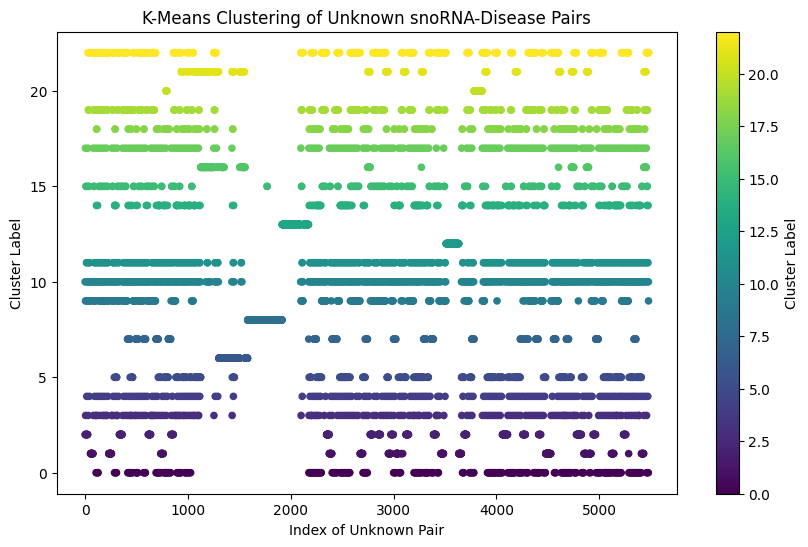

In [659]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(labels)), labels, c=labels, cmap='viridis', s=20)
plt.title('K-Means Clustering of Unknown snoRNA-Disease Pairs')
plt.xlabel('Index of Unknown Pair')
plt.ylabel('Cluster Label')
plt.colorbar(label='Cluster Label')
plt.show()

#### Final datasets are being prepared

In [660]:
sampled_disease_rna_tup = [[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]
n = 0
for i in range(len(disease_rna_tup)):
    sampled_disease_rna_tup[i] = random.sample(disease_rna_tup[i], int((len(disease_rna_tup[i])/len(labels)) * len(known)))

dataset = []
for rna in range(known_association.shape[0]):
    for disease in range(known_association.shape[1]):
        for i in range(len(sampled_disease_rna_tup)):
            if (rna, disease) in sampled_disease_rna_tup[i]:
                dataset.append((rna, disease))


for rna in range(known_association.shape[0]):
    for disease in range(known_association.shape[1]):
        if (rna, disease) in known:
            dataset.append((rna, disease))

length = len(dataset)
print(length)


906


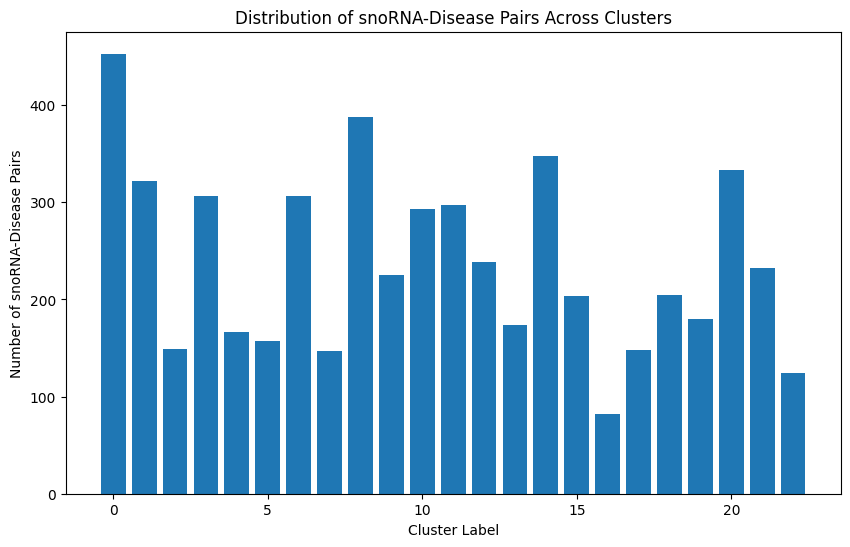

In [661]:
plt.figure(figsize=(10, 6))
plt.bar(range(n_clusters), [len(cluster) for cluster in disease_rna_tup.values()])
plt.xlabel('Cluster Label')
plt.ylabel('Number of snoRNA-Disease Pairs')
plt.title('Distribution of snoRNA-Disease Pairs Across Clusters')
plt.show()

In [662]:
selected_x = []
selected_y = []
#now I am just taking only the similarities of disease and rna of sampled data.
for data in dataset:
    a = disease_semantic_similarity[data[1], :].tolist()
    b = snoRNA_functional_similarity[data[0], :].tolist()
    q = a + b
    selected_x.append(q)

    if (data[0], data[1]) in known:
        selected_y.append(1)
    else:
        selected_y.append(0)

selected_data_np = np.array(selected_x)
selected_label_np = np.array(selected_y)



# Model

## Pre Poressesing Fun

#### Model Config 

In [663]:

N_SPLITS = 5
RANDOM_STATE = 42

SVM_PARAM_GRID = {
    "clf__C": [0.1, 1, 10],
    "clf__gamma": ["scale", 0.1],
    "clf__kernel": ["rbf", "linear"]
}

RF_PARAMS = {'n_estimators': 200, 'random_state': RANDOM_STATE}
LOGISTIC_PARAMS = {'max_iter': 1000, 'solver': 'lbfgs'}
XGB_ROUNDS = 200
LGB_ROUNDS = 500
DNN_EPOCHS = 40
DNN_BATCH = 64

SAVE_MODELS = False
SAVE_PLOTS = False
PDF_REPORT_NAME = os.path.join(OUTPUT_DIR, f"ml_hybrid_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
COMPARISON_CSV = os.path.join(OUTPUT_DIR, "model_comparison_table_hybrid.csv")


### Utilities

In [664]:
def ensure_array(X):
    try:
        import scipy.sparse as sp
        if sp.issparse(X):
            return X
    except Exception:
        pass    
    return np.asarray(X)

In [665]:
def build_dnn_model(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

In [666]:
def plot_confusion_matrix(cm, classes, title='Confusion matrix', figsize=(5,4)):
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(int(cm[i, j]), 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

In [667]:
def plot_classification_text(report_text, title='Classification Report', figsize=(8,6)):
    plt.figure(figsize=figsize)
    plt.axis('off')
    plt.text(0, 1, title, fontsize=14, weight='bold')
    plt.text(0, 0.95, report_text, fontsize=9, family='monospace')
    plt.tight_layout()

In [668]:
def save_model(obj, path):
    try:
        if hasattr(obj, 'save') and (path.endswith('.h5') or path.endswith('.hdf5')):
            obj.save(path)
        else:
            joblib.dump(obj, path)
    except Exception as e:
        print(f"Warning: could not save model to {path}: {e}")

### Feature Selection

In [669]:
def ga_feature_selection(X, y, estimator_builder, n_generations=15, pop_size=20, crossover_rate=0.8, mutation_rate=0.02, random_state=RANDOM_STATE):
    """
    Binary GA: chromosome bits indicate whether feature is selected.
    estimator_builder: callable -> returns a fresh estimator (must have fit/predict_proba)
    Returns: best_mask (boolean array)
    """
    rng = np.random.RandomState(random_state)
    n_features = X.shape[1]

    def random_individual():
        # ensure at least one feature
        mask = rng.rand(n_features) < 0.5
        if not mask.any():
            mask[rng.randint(n_features)] = True
        return mask

    def fitness(mask):
        # evaluate by cross-validated ROC AUC (quick 3-fold)
        if mask.sum() == 0:
            return 0.0
        Xm = X[:, mask]
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
        scores = []
        for tr, te in skf.split(Xm, y):
            est = estimator_builder()
            try:
                est.fit(Xm[tr], y[tr])
                proba = est.predict_proba(Xm[te])[:, 1]
                scores.append(roc_auc_score(y[te], proba))
            except Exception:
                # fallback to predict
                try:
                    pred = est.fit(Xm[tr], y[tr]).predict(Xm[te])
                    scores.append(roc_auc_score(y[te], pred))
                except Exception:
                    scores.append(0.0)
        return float(np.mean(scores))

    # init population
    pop = [random_individual() for _ in range(pop_size)]
    pop_fitness = [fitness(ind) for ind in pop]

    for gen in range(n_generations):
        # sort by fitness descending
        idxs = np.argsort(pop_fitness)[::-1]
        pop = [pop[i] for i in idxs]
        pop_fitness = [pop_fitness[i] for i in idxs]
        # elitism: keep top 2
        new_pop = pop[:2]
        while len(new_pop) < pop_size:
            # selection (tournament)
            a, b = rng.randint(pop_size), rng.randint(pop_size)
            parent1 = pop[a] if pop_fitness[a] > pop_fitness[b] else pop[b]
            a, b = rng.randint(pop_size), rng.randint(pop_size)
            parent2 = pop[a] if pop_fitness[a] > pop_fitness[b] else pop[b]
            # crossover
            if rng.rand() < crossover_rate:
                cx_point = rng.randint(1, n_features-1)
                child = np.concatenate([parent1[:cx_point], parent2[cx_point:]]).astype(bool)
            else:
                child = parent1.copy()
            # mutation
            for i in range(n_features):
                if rng.rand() < mutation_rate:
                    child[i] = not child[i]
            if not child.any():
                child[rng.randint(n_features)] = True
            new_pop.append(child)
        pop = new_pop
        pop_fitness = [fitness(ind) for ind in pop]
        # debug
        best_idx = int(np.argmax(pop_fitness))
        print(f"[GA] Gen {gen+1}/{n_generations} best fitness: {pop_fitness[best_idx]:.4f} selected {pop[best_idx].sum()} features")
    best_mask = pop[int(np.argmax(pop_fitness))]
    return best_mask


In [670]:
def pso_feature_selection(X, y, estimator_builder, n_particles=20, iters=20, w=0.72, c1=1.49, c2=1.49, random_state=RANDOM_STATE):
    """
    Simple PSO: each particle is a vector of continuous weights in [0,1]; threshold to select features
    Returns: best_mask boolean array
    """
    rng = np.random.RandomState(random_state)
    n_features = X.shape[1]

    def fitness_from_weights(wvec):
        mask = wvec > 0.5
        if mask.sum() == 0:
            return 0.0
        Xm = X[:, mask]
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
        scores = []
        for tr, te in skf.split(Xm, y):
            est = estimator_builder()
            try:
                est.fit(Xm[tr], y[tr])
                proba = est.predict_proba(Xm[te])[:, 1]
                scores.append(roc_auc_score(y[te], proba))
            except Exception:
                try:
                    pred = est.fit(Xm[tr], y[tr]).predict(Xm[te])
                    scores.append(roc_auc_score(y[te], pred))
                except Exception:
                    scores.append(0.0)
        return float(np.mean(scores))

    # initialize
    particles = [rng.rand(n_features) for _ in range(n_particles)]
    velocities = [rng.normal(scale=0.1, size=n_features) for _ in range(n_particles)]
    pbest = particles.copy()
    pbest_scores = [fitness_from_weights(p) for p in particles]
    gbest_idx = int(np.argmax(pbest_scores))
    gbest = pbest[gbest_idx].copy()
    gbest_score = pbest_scores[gbest_idx]
    for it in range(iters):
        for i in range(n_particles):
            r1 = rng.rand(n_features)
            r2 = rng.rand(n_features)
            velocities[i] = w*velocities[i] + c1*r1*(pbest[i]-particles[i]) + c2*r2*(gbest-particles[i])
            particles[i] = particles[i] + velocities[i]
            # clamp to [0,1]
            particles[i] = np.clip(particles[i], 0.0, 1.0)
            score = fitness_from_weights(particles[i])
            if score > pbest_scores[i]:
                pbest[i] = particles[i].copy()
                pbest_scores[i] = score
                if score > gbest_score:
                    gbest = pbest[i].copy()
                    gbest_score = score
        print(f"[PSO] Iter {it+1}/{iters} gbest_score: {gbest_score:.4f}")
    best_mask = gbest > 0.5
    if not best_mask.any():
        # pick top-1 weight
        best_mask[np.argmax(gbest)] = True
    return best_mask

### Optimization

In [671]:
def optuna_tune_svm(X, y, n_trials=30, random_state=RANDOM_STATE):
    if not HAS_OPTUNA:
        raise RuntimeError("Optuna not installed.")
    def objective(trial):
        C = trial.suggest_loguniform('C', 1e-3, 1e2)
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto', 0.1, 1, 10])
        kernel = trial.suggest_categorical('kernel', ['rbf', 'linear'])
        clf = SVC(C=C, gamma=gamma, kernel=kernel, probability=True, random_state=random_state)
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
        scores = []
        for tr, te in skf.split(X, y):
            clf.fit(X[tr], y[tr])
            try:
                proba = clf.predict_proba(X[te])[:,1]
                scores.append(roc_auc_score(y[te], proba))
            except Exception:
                scores.append(roc_auc_score(y[te], clf.predict(X[te])))
        return np.mean(scores)
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=random_state))
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

### Constant

In [672]:
random_state = 42
n_splits = 5

X, y = make_classification(n_samples=1000, n_features=30, n_informative=10, n_redundant=5, random_state=random_state, weights=[0.7,0.3])

In [673]:
pdf_pages = PdfPages(PDF_REPORT_NAME)


skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
scaler = StandardScaler()

results_summary = []

In [674]:
def _save(obj, name):
        path = os.path.join(OUTPUT_DIR, name)
        save_model(obj, path)

## Model Evaluation

In [675]:
X = ensure_array(X)
y = np.asarray(y)

# Title page
plt.figure(figsize=(11,8.5)); plt.axis('off')
title = "ML Hybrid Models Comparison Report"
meta = f"Generated: {datetime.now().isoformat()}\nDataset samples: {len(y)}\nModels: {', '.join("Logistic")}\nStratifiedKFold: {n_splits} splits\nRandom seed: {random_state}"
plt.text(0.5, 0.6, title, ha='center', va='center', fontsize=26, weight='bold')
plt.text(0.5, 0.45, meta, ha='center', va='center', fontsize=10)
plt.tight_layout(); pdf_pages.savefig(); plt.close()

combined_rocs = {} 

mean_fpr = np.linspace(0,1,200)
fold_tprs = []
fold_fprs = []
fold_precisions = []
fold_recalls = []
roc_aucs = []
aupr_values = []
accs = []
f1s = []
last_y_test = None; last_pred = None; last_proba = None
fold_idx = 0
shap_objects = []
shap_available_for_model = False    

### Logistic

In [676]:
model_name = "logistic"
   
for train_idx, test_idx in skf.split(X,y):
    fold_idx += 1
    print(f"logistic Fold {fold_idx}/5 ...", end=' ')
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    # X_train_scaled, X_test_scaled = X_train, X_test
    

    model = LogisticRegression(**LOGISTIC_PARAMS)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:,1]
    pred = model.predict(X_test)
    _save(model, f"logistic_fold{fold_idx}.joblib")
    try:
            expl = shap.LinearExplainer(model, X_train, feature_perturbation="interventional")
            shap_objects.append(('linear', expl, X_test))
            shap_available_for_model = True
    except Exception:
            raise RuntimeError(f"Unknown model: {model_name}")

    try:
        roc = roc_auc_score(y_test, proba)
    except Exception:
        roc = roc_auc_score(y_test, pred)
    roc_aucs.append(roc)
    accs.append(accuracy_score(y_test, pred))
    f1s.append(f1_score(y_test, pred, zero_division=0))

    fpr, tpr, _ = roc_curve(y_test, proba)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    fold_tprs.append(interp_tpr)
    fold_fprs.append(mean_fpr)
    precision, recall, _ = precision_recall_curve(y_test, proba)
    recall_rev = recall[::-1]; precision_rev = precision[::-1]
    interp_precision = np.interp(mean_fpr, recall_rev, precision_rev)  # reuse same grid
    fold_precisions.append(interp_precision)
    fold_recalls.append(mean_fpr)
    aupr_values.append(auc(recall, precision))
    last_y_test = y_test; last_proba = proba; last_pred = pred
    print(f"ROC AUC: {roc:.4f}, Acc: {accs[-1]:.4f}, F1: {f1s[-1]:.4f}")




logistic Fold 1/5 ... ROC AUC: 0.8745, Acc: 0.8150, F1: 0.6667
logistic Fold 2/5 ... ROC AUC: 0.9193, Acc: 0.8500, F1: 0.7414
logistic Fold 3/5 ... ROC AUC: 0.9099, Acc: 0.8200, F1: 0.7049
logistic Fold 4/5 ... ROC AUC: 0.9288, Acc: 0.8450, F1: 0.7350
logistic Fold 5/5 ... ROC AUC: 0.9110, Acc: 0.8550, F1: 0.7563


### Random Forest

In [677]:
# model_name = "Random Forest"
   
# for train_idx, test_idx in skf.split(X,y):
#     fold_idx += 1
#     print(f"Random Forest Fold {fold_idx}/ ...", end=' ')
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]

#     # define helper to save model
#     def _save(obj, name):
#         path = os.path.join(OUTPUT_DIR, name)
#         save_model(obj, path)

#     model = RandomForestClassifier(**RF_PARAMS)
#     model.fit(X_train, y_train)
#     proba = model.predict_proba(X_test)[:,1]
#     pred = model.predict(X_test)
#     _save(model, f"rf_fold{fold_idx}.joblib")
#     if HAS_SHAP:
#         try:
#             expl = shap.TreeExplainer(model)
#             shap_objects.append(('tree', expl, X_test))
#             shap_available_for_model = True
#         except Exception:
#             pass

#     try:
#         roc = roc_auc_score(y_test, proba)
#     except Exception:
#         roc = roc_auc_score(y_test, pred)
#     roc_aucs.append(roc)
#     accs.append(accuracy_score(y_test, pred))
#     f1s.append(f1_score(y_test, pred, zero_division=0))

#     fpr, tpr, _ = roc_curve(y_test, proba)
#     interp_tpr = np.interp(mean_fpr, fpr, tpr)
#     interp_tpr[0] = 0.0
#     fold_tprs.append(interp_tpr)
#     fold_fprs.append(mean_fpr)
#     precision, recall, _ = precision_recall_curve(y_test, proba)
#     recall_rev = recall[::-1]; precision_rev = precision[::-1]
#     interp_precision = np.interp(mean_fpr, recall_rev, precision_rev)  # reuse same grid
#     fold_precisions.append(interp_precision)
#     fold_recalls.append(mean_fpr)
#     aupr_values.append(auc(recall, precision))
#     last_y_test = y_test; last_proba = proba; last_pred = pred
#     print(f"ROC AUC: {roc:.4f}, Acc: {accs[-1]:.4f}, F1: {f1s[-1]:.4f}")

### svm

In [678]:
# model_name = "SVM"
   
# for train_idx, test_idx in skf.split(X,y):
#     fold_idx += 1
#     print(f"SVM Fold {fold_idx}/ 5 ...", end=' ')
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]

#     # define helper to save model
#     def _save(obj, name):
#         path = os.path.join(OUTPUT_DIR, name)
#         save_model(obj, path)

#     model = RandomForestClassifier(**RF_PARAMS)
#     model.fit(X_train, y_train)
#     proba = model.predict_proba(X_test)[:,1]
#     pred = model.predict(X_test)
#     _save(model, f"rf_fold{fold_idx}.joblib")
#     if HAS_SHAP:
#         try:
#             expl = shap.TreeExplainer(model)
#             shap_objects.append(('tree', expl, X_test))
#             shap_available_for_model = True
#         except Exception:
#             pass

#     try:
#         roc = roc_auc_score(y_test, proba)
#     except Exception:
#         roc = roc_auc_score(y_test, pred)
#     roc_aucs.append(roc)
#     accs.append(accuracy_score(y_test, pred))
#     f1s.append(f1_score(y_test, pred, zero_division=0))

#     fpr, tpr, _ = roc_curve(y_test, proba)
#     interp_tpr = np.interp(mean_fpr, fpr, tpr)
#     interp_tpr[0] = 0.0
#     fold_tprs.append(interp_tpr)
#     fold_fprs.append(mean_fpr)
#     precision, recall, _ = precision_recall_curve(y_test, proba)
#     recall_rev = recall[::-1]; precision_rev = precision[::-1]
#     interp_precision = np.interp(mean_fpr, recall_rev, precision_rev)  # reuse same grid
#     fold_precisions.append(interp_precision)
#     fold_recalls.append(mean_fpr)
#     aupr_values.append(auc(recall, precision))
#     last_y_test = y_test; last_proba = proba; last_pred = pred
#     print(f"ROC AUC: {roc:.4f}, Acc: {accs[-1]:.4f}, F1: {f1s[-1]:.4f}")

### xgb

In [679]:
# model_name = "SVM"
   
# for train_idx, test_idx in skf.split(X,y):
#     fold_idx += 1
#     print(f"SVM Fold {fold_idx}/ 5 ...", end=' ')
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]

#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     # define helper to save model
#     def _save(obj, name):
#         path = os.path.join(OUTPUT_DIR, name)
#         save_model(obj, path)

#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dtest = xgb.DMatrix(X_test, label=y_test)
#     params = {'objective':'binary:logistic','eval_metric':'auc','seed':random_state,'verbosity':0}
#     bst = xgb.train(params, dtrain, num_boost_round=XGB_ROUNDS)
#     proba = bst.predict(dtest)
#     pred = (proba >= 0.5).astype(int)
#     _save(bst, f"xgb_fold{fold_idx}.model")
#     if HAS_SHAP:
#         try:
#             expl = shap.Explainer(bst)
#             shap_objects.append(('xgb', expl, xgb.DMatrix(X_test)))
#             shap_available_for_model = True
#         except Exception:
#             pass
#     try:
#         roc = roc_auc_score(y_test, proba)
#     except Exception:
#         roc = roc_auc_score(y_test, pred)
#     roc_aucs.append(roc)
#     accs.append(accuracy_score(y_test, pred))
#     f1s.append(f1_score(y_test, pred, zero_division=0))

#     fpr, tpr, _ = roc_curve(y_test, proba)
#     interp_tpr = np.interp(mean_fpr, fpr, tpr)
#     interp_tpr[0] = 0.0
#     fold_tprs.append(interp_tpr)
#     fold_fprs.append(mean_fpr)
#     precision, recall, _ = precision_recall_curve(y_test, proba)
#     recall_rev = recall[::-1]; precision_rev = precision[::-1]
#     interp_precision = np.interp(mean_fpr, recall_rev, precision_rev)  # reuse same grid
#     fold_precisions.append(interp_precision)
#     fold_recalls.append(mean_fpr)
#     aupr_values.append(auc(recall, precision))
#     last_y_test = y_test; last_proba = proba; last_pred = pred
#     print(f"ROC AUC: {roc:.4f}, Acc: {accs[-1]:.4f}, F1: {f1s[-1]:.4f}")

### xgb

In [680]:
# model_name = "XGB"
   
# for train_idx, test_idx in skf.split(X,y):
#     fold_idx += 1
#     print(f"{model_name} Fold {fold_idx}/ 5 ...", end=' ')
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]

#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     # define helper to save model
#     def _save(obj, name):
#         path = os.path.join(OUTPUT_DIR, name)
#         save_model(obj, path)

#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dtest = xgb.DMatrix(X_test, label=y_test)
#     params = {'objective':'binary:logistic','eval_metric':'auc','seed':random_state,'verbosity':0}
#     bst = xgb.train(params, dtrain, num_boost_round=XGB_ROUNDS)
#     proba = bst.predict(dtest)
#     pred = (proba >= 0.5).astype(int)
#     _save(bst, f"xgb_fold{fold_idx}.model")
#     if HAS_SHAP:
#         try:
#             expl = shap.Explainer(bst)
#             shap_objects.append(('xgb', expl, xgb.DMatrix(X_test)))
#             shap_available_for_model = True
#         except Exception:
#             pass
#     try:
#         roc = roc_auc_score(y_test, proba)
#     except Exception:
#         roc = roc_auc_score(y_test, pred)
#     roc_aucs.append(roc)
#     accs.append(accuracy_score(y_test, pred))
#     f1s.append(f1_score(y_test, pred, zero_division=0))

#     fpr, tpr, _ = roc_curve(y_test, proba)
#     interp_tpr = np.interp(mean_fpr, fpr, tpr)
#     interp_tpr[0] = 0.0
#     fold_tprs.append(interp_tpr)
#     fold_fprs.append(mean_fpr)
#     precision, recall, _ = precision_recall_curve(y_test, proba)
#     recall_rev = recall[::-1]; precision_rev = precision[::-1]
#     interp_precision = np.interp(mean_fpr, recall_rev, precision_rev)  # reuse same grid
#     fold_precisions.append(interp_precision)
#     fold_recalls.append(mean_fpr)
#     aupr_values.append(auc(recall, precision))
#     last_y_test = y_test; last_proba = proba; last_pred = pred
#     print(f"ROC AUC: {roc:.4f}, Acc: {accs[-1]:.4f}, F1: {f1s[-1]:.4f}")

### Post Step

#### summarize

In [681]:
mean_tpr = np.mean(fold_tprs, axis=0) if len(fold_tprs) else np.zeros_like(mean_fpr)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(roc_aucs) if len(roc_aucs)>0 else 0.0
mean_precision = np.mean(fold_precisions, axis=0) if len(fold_precisions) else np.zeros_like(mean_fpr)
mean_aupr = auc(mean_fpr, mean_precision) if len(mean_precision)>0 else 0.0

#### ROC figure (per-model)

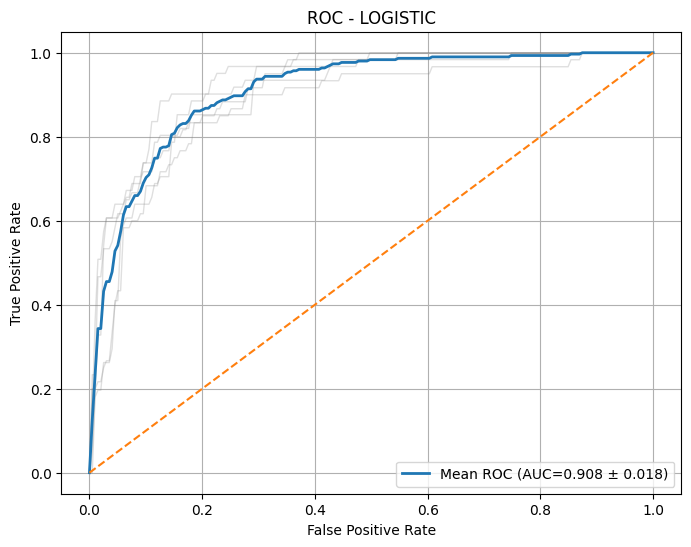

In [682]:
plt.figure(figsize=(8,6))
for fpr, tpr in zip(fold_fprs, fold_tprs):
    plt.plot(fpr, tpr, color='gray', lw=1, alpha=0.25)
plt.plot(mean_fpr, mean_tpr, lw=2, label=f"Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})")
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC - {model_name.upper()}")
plt.legend(); plt.grid(True)
roc_fig_path = os.path.join(OUTPUT_DIR, f"{model_name}_roc.png")
if SAVE_PLOTS:
    plt.savefig(roc_fig_path, bbox_inches='tight')
    pdf_pages.savefig(); plt.close()

#### PR figure

In [683]:
plt.figure(figsize=(8,6))
for r,p in zip(fold_recalls, fold_precisions):
    plt.plot(r,p, color='gray', lw=1, alpha=0.25)
plt.plot(mean_fpr, mean_precision, lw=2, label=f"Mean PR (AUPR={mean_aupr:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision-Recall - {model_name.upper()}")
plt.legend(); 
plt.grid(True)
pr_fig_path = os.path.join(OUTPUT_DIR, f"{model_name}_pr.png")
if SAVE_PLOTS:
    plt.savefig(pr_fig_path, bbox_inches='tight')
pdf_pages.savefig(); plt.close()

#### confusion matrix + classification report (last fold)

In [684]:
if last_y_test is not None and last_pred is not None:
    cm = confusion_matrix(last_y_test, last_pred)
    plot_confusion_matrix(cm, classes=['0','1'], title=f'Confusion Matrix - {model_name.upper()} (last fold)')
    cm_path = os.path.join(OUTPUT_DIR, f"{model_name}_confusion.png")
    if SAVE_PLOTS:
        plt.savefig(cm_path, bbox_inches='tight')
    pdf_pages.savefig(); plt.close()

    cls_report = classification_report(last_y_test, last_pred, zero_division=0)
    plot_classification_text(cls_report, title=f'Classification Report - {model_name.upper()} (last fold)')
    rpt_path = os.path.join(OUTPUT_DIR, f"{model_name}_classification_report.png")
    if SAVE_PLOTS:
        plt.savefig(rpt_path, bbox_inches='tight')
    pdf_pages.savefig(); plt.close()
else:
    cls_report = "Not available"

#### SHAP (first available explainer)

In [685]:
shap_paths = []
if HAS_SHAP and shap_available_for_model and len(shap_objects)>0:
    try:
        expl_type, expl, sample_data = shap_objects[0]
        plt.figure(figsize=(8,6))
        try:
            shap.summary_plot(expl, sample_data, show=False)
        except TypeError:
            shap.summary_plot(sample_data, expl, show=False)
        shap_path = os.path.join(OUTPUT_DIR, f"{model_name}_shap_summary.png")
        plt.tight_layout()
        if SAVE_PLOTS:
            plt.savefig(shap_path, bbox_inches='tight')
        pdf_pages.savefig(); plt.close()
        shap_paths.append(shap_path)
    except Exception as e:
        print("SHAP plotting failed for", model_name, e)
    results_summary.append({
            'model': model_name,
            'mean_roc_auc': float(np.mean(roc_aucs)) if len(roc_aucs)>0 else 0.0,
            'std_roc_auc': float(std_auc),
            'mean_aupr': float(np.mean(aupr_values)) if len(aupr_values)>0 else 0.0,
            'mean_accuracy': float(np.mean(accs)) if len(accs)>0 else 0.0,
            'mean_f1': float(np.mean(f1s)) if len(f1s)>0 else 0.0
        })

    combined_rocs[model_name] = (mean_fpr, mean_tpr, mean_auc, std_auc)

SHAP plotting failed for logistic 'LinearExplainer' object has no attribute 'shape'


<Figure size 800x600 with 0 Axes>

#### Comparison table

In [686]:
df = pd.DataFrame(results_summary).sort_values(by='mean_roc_auc', ascending=False).reset_index(drop=True)
df.to_csv(COMPARISON_CSV, index=False)
print("\n=== Comparison Table ===")
print(df)


=== Comparison Table ===
      model  mean_roc_auc  std_roc_auc  mean_aupr  mean_accuracy   mean_f1
0  logistic      0.908685      0.01838   0.802408          0.837  0.720862


#### Append comparison table to PDF

In [687]:
plt.figure(figsize=(11,8.5)); plt.axis('off')
plt.text(0.02,0.98,"Model Comparison Table (sorted by mean ROC AUC)", fontsize=14, weight='bold', va='top')
plt.text(0.02,0.92, df.to_string(index=False), fontsize=8, family='monospace', va='top')
pdf_pages.savefig(); plt.close()

#### Combined ROC plot across all models

In [688]:
plt.figure(figsize=(10,8))
for m, data in combined_rocs.items():
    mean_fpr, mean_tpr, mean_auc, std_auc = data
    plt.plot(mean_fpr, mean_tpr, lw=2, label=f"{m} (AUC={mean_auc:.3f} ± {std_auc:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='black', alpha=0.6)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Combined ROC - All Models")
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
combined_path = os.path.join(OUTPUT_DIR, "combined_roc_all_models.png")
if SAVE_PLOTS:
    plt.savefig(combined_path, bbox_inches='tight')
    pdf_pages.savefig()
    pdf_pages.close()
plt.close()
print(f"\nPDF report saved to: {PDF_REPORT_NAME}")
print(f"Comparison CSV saved to: {COMPARISON_CSV}")
print(f"Combined ROC saved to: {combined_path}")


PDF report saved to: hybrid_model_on_PSnoD\ml_hybrid_report_20251205_124453.pdf
Comparison CSV saved to: hybrid_model_on_PSnoD\model_comparison_table_hybrid.csv
Combined ROC saved to: hybrid_model_on_PSnoD\combined_roc_all_models.png


### Evaluate